# Osteoporosis Risk Prediction — End-to-End ML Project

**Objective:** Build a professional, well-documented machine learning pipeline to predict osteoporosis risk using patient health, lifestyle, demographic, hormonal, nutritional, and medical history factors.

**Contents:** Imports, Data Loading, Cleaning, EDA, Feature Engineering, Modeling, Hyperparameter Tuning, Evaluation, Insights & Recommendations.

In [9]:
# 1) Import Libraries
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, precision_recall_curve)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

# Optional - for imbalance handling
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

# Visualization theme
sns.set(style='darkgrid')
plt.rcParams['figure.figsize'] = (10,6)

In [10]:
# 2) Load Dataset
DATA_PATH = 'osteoporosis.csv'  # file should be in same folder as notebook
assert os.path.exists(DATA_PATH), f"Data file not found at {DATA_PATH}. Place `osteoporosis.csv` in this folder."
df = pd.read_csv(DATA_PATH)
print('Dataset loaded: ', DATA_PATH)
df.shape

Dataset loaded:  osteoporosis.csv


(1958, 16)

In [11]:
# Quick peek at the data
display(df.head())
df.info()

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1


<class 'pandas.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Id                   1958 non-null   int64
 1   Age                  1958 non-null   int64
 2   Gender               1958 non-null   str  
 3   Hormonal Changes     1958 non-null   str  
 4   Family History       1958 non-null   str  
 5   Race/Ethnicity       1958 non-null   str  
 6   Body Weight          1958 non-null   str  
 7   Calcium Intake       1958 non-null   str  
 8   Vitamin D Intake     1958 non-null   str  
 9   Physical Activity    1958 non-null   str  
 10  Smoking              1958 non-null   str  
 11  Alcohol Consumption  970 non-null    str  
 12  Medical Conditions   1311 non-null   str  
 13  Medications          973 non-null    str  
 14  Prior Fractures      1958 non-null   str  
 15  Osteoporosis         1958 non-null   int64
dtypes: int64(3), str(13)
memory usage: 

In [12]:
# 3) Dataset overview: shape, columns, dtypes, missing, duplicates
overview = {
    'shape': df.shape,
    'columns': list(df.columns),
    'dtypes': df.dtypes.to_dict(),
    'missing_values': df.isnull().sum().sort_values(ascending=False).head(20),
    'duplicates': df.duplicated().sum()
}
overview['shape'], overview['duplicates'], overview['missing_values']

((1958, 16),
 np.int64(0),
 Alcohol Consumption    988
 Medications            985
 Medical Conditions     647
 Id                       0
 Family History           0
 Age                      0
 Gender                   0
 Hormonal Changes         0
 Calcium Intake           0
 Body Weight              0
 Race/Ethnicity           0
 Vitamin D Intake         0
 Smoking                  0
 Physical Activity        0
 Prior Fractures          0
 Osteoporosis             0
 dtype: int64)

## Data Cleaning
- Handle missing values and duplicates sensibly. The code below makes conservative choices: drop duplicates, impute simple missing values (mean/median for numeric, mode for categorical). Customize for clinical datasets as needed.

In [13]:
# Drop duplicates
before_dup = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after_dup = df.shape[0]
print(f'Dropped {before_dup - after_dup} duplicate rows')

# Impute missing values with simple strategies - record what's done
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Numeric cols:', num_cols)
print('Categorical cols:', cat_cols)

# Numeric imputation: median
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# Categorical imputation: mode
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].mode().iloc[0], inplace=True)

print('Missing values after imputation:')
print(df.isnull().sum().sum())

Dropped 0 duplicate rows
Numeric cols: ['Id', 'Age', 'Osteoporosis']
Categorical cols: ['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures']
Missing values after imputation:
2620


## Exploratory Data Analysis (EDA)
We'll perform univariate, bivariate and multivariate analysis. The code is written to adapt to available columns in the dataset.

Using detected target column: Osteoporosis


Osteoporosis
1    979
0    979
Name: count, dtype: int64

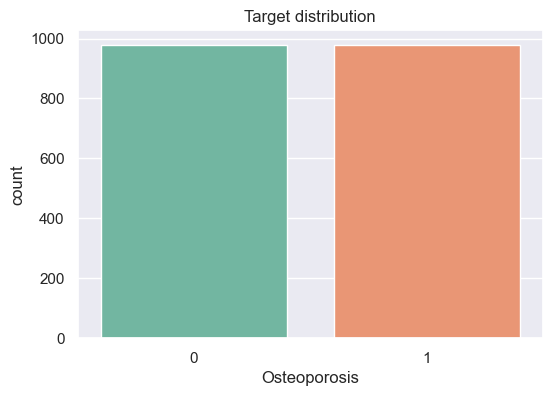

In [14]:
# Identify likely target column automatically if possible
target_candidates = [c for c in df.columns if c.lower() in ['osteoporosis','risk','target','class','label','outcome']]
if len(target_candidates) > 0:
    target = target_candidates[0]
    print('Using detected target column:', target)
else:
    # fallback: ask user to set target variable name manually
    print('No obvious target column found. Please set `target` variable to the name of the label column.')
    target = None

# If target exists, show distribution
if target is not None:
    display(df[target].value_counts(dropna=False))
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=target, palette='Set2')
    plt.title('Target distribution')
    plt.show()

### Univariate analysis — numeric features

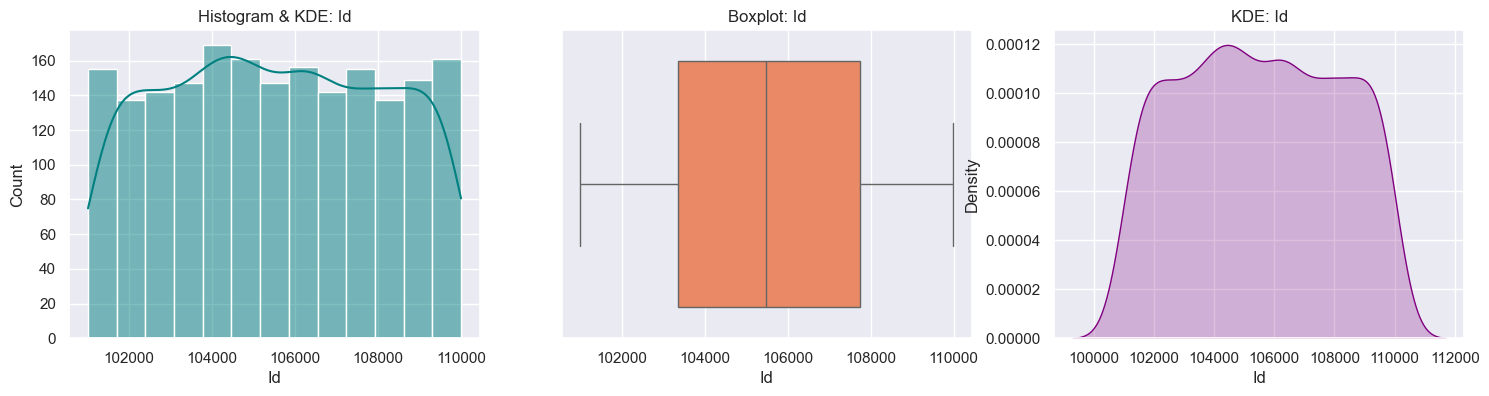

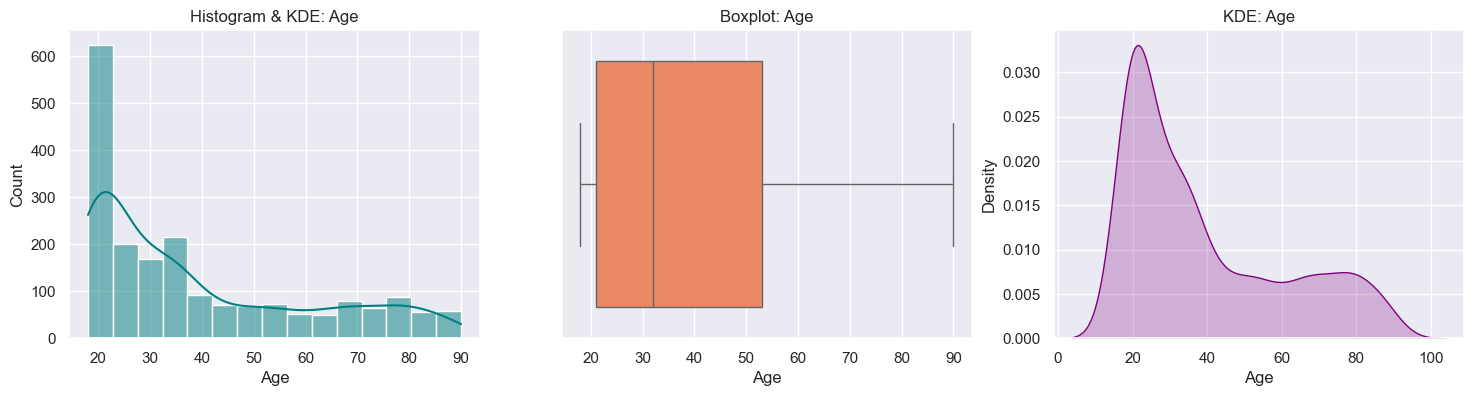

In [15]:
# Plot histograms, boxplots and KDEs for numeric columns
num_to_plot = [c for c in num_cols if c != target][:8]  # limit to first 8 for display
for c in num_to_plot:
    fig, axes = plt.subplots(1,3, figsize=(18,4))
    sns.histplot(df[c], kde=True, ax=axes[0], color='teal')
    axes[0].set_title(f'Histogram & KDE: {c}')
    sns.boxplot(x=df[c], ax=axes[1], color='coral')
    axes[1].set_title(f'Boxplot: {c}')
    sns.kdeplot(df[c].dropna(), ax=axes[2], shade=True, color='purple')
    axes[2].set_title(f'KDE: {c}')
    plt.show()

### Univariate analysis — categorical features

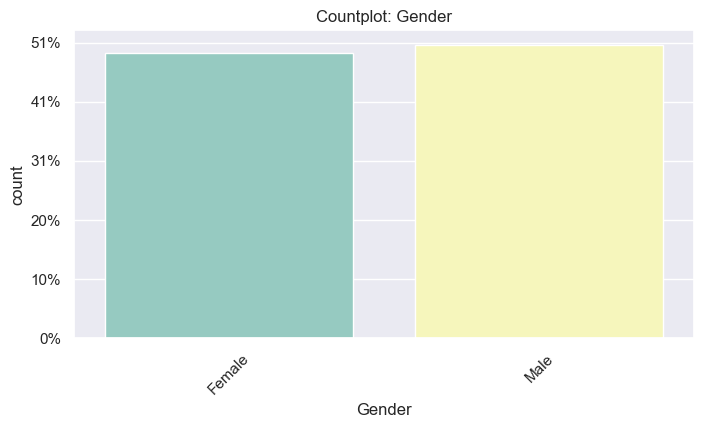

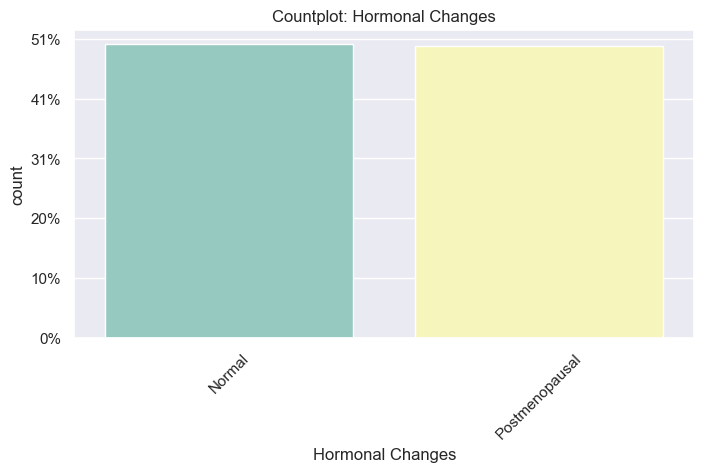

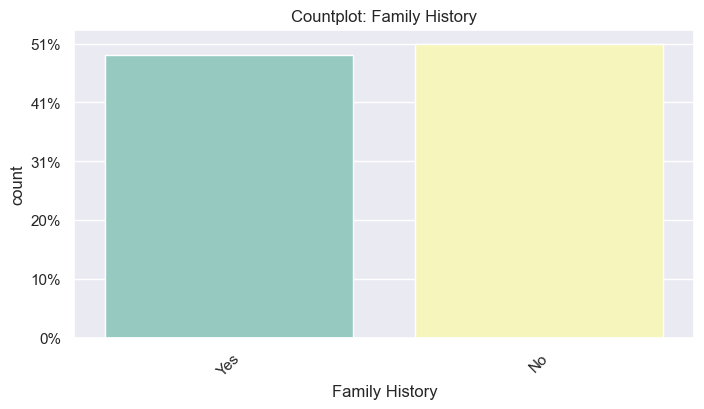

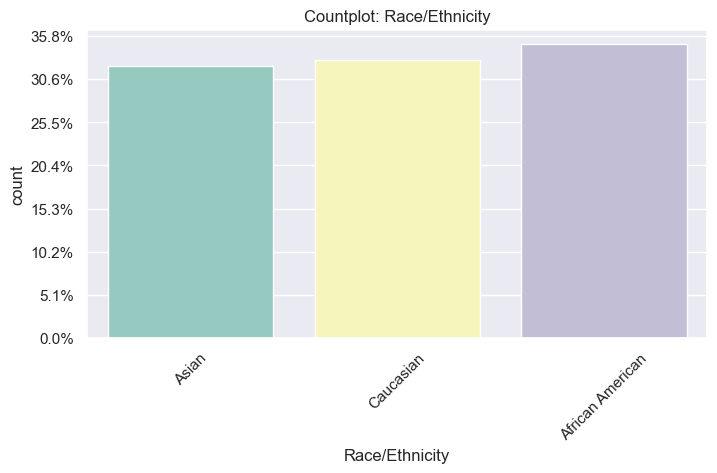

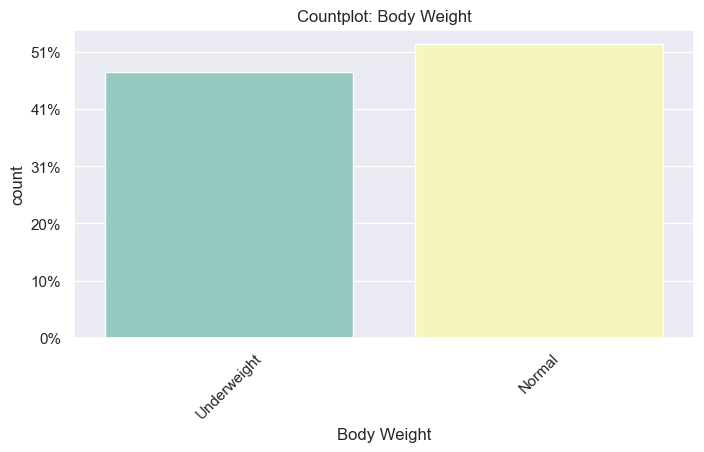

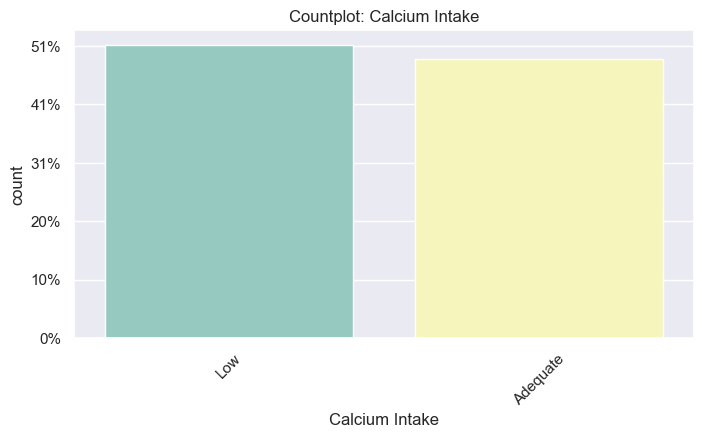

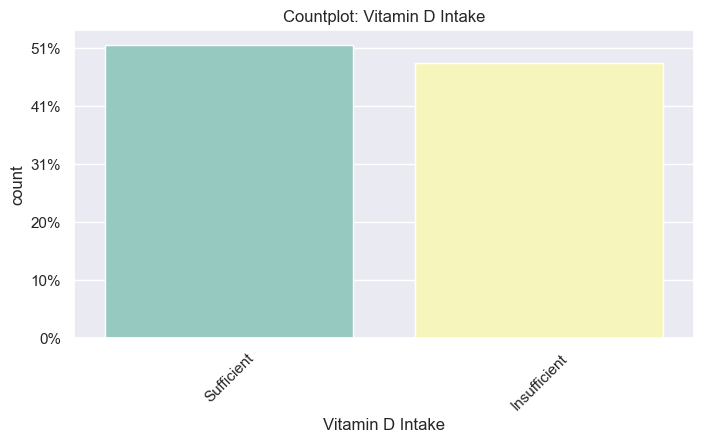

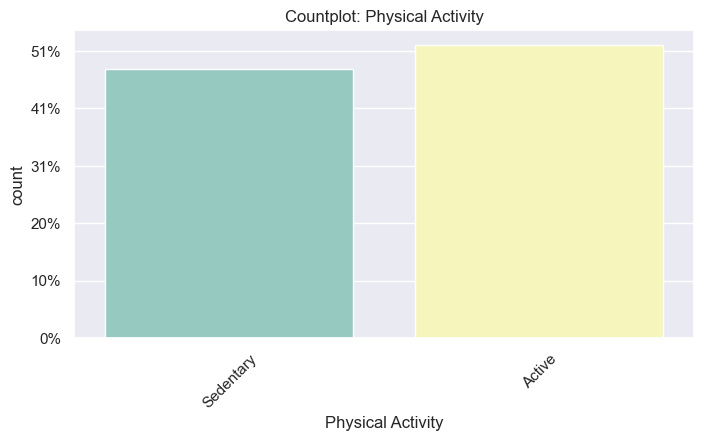

In [16]:
cat_to_plot = [c for c in cat_cols if c != target][:8]
for c in cat_to_plot:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=c, palette='Set3')
    plt.title(f'Countplot: {c}')
    plt.xticks(rotation=45)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(len(df)))
    plt.show()

## Bivariate analysis (selected healthcare relationships)
The notebook will attempt to analyze common relationships: age, hormonal changes, smoking, alcohol, physical activity, calcium intake, medical conditions, medications, family history vs osteoporosis outcome. If a column is missing, that section will be skipped.

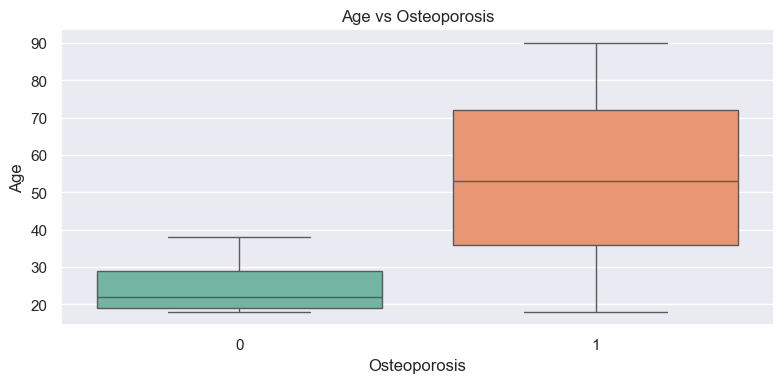

<Figure size 800x400 with 0 Axes>

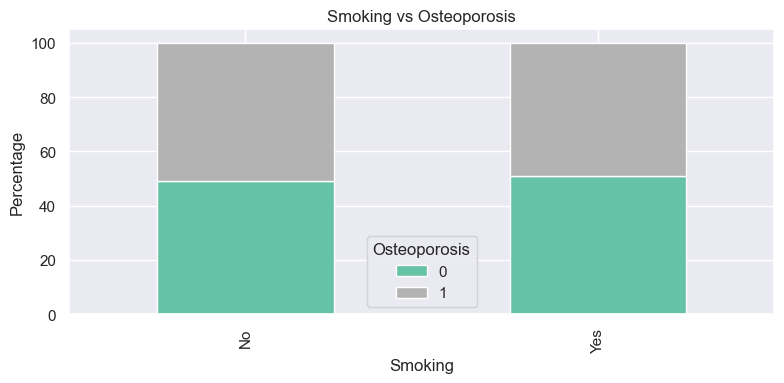

<Figure size 800x400 with 0 Axes>

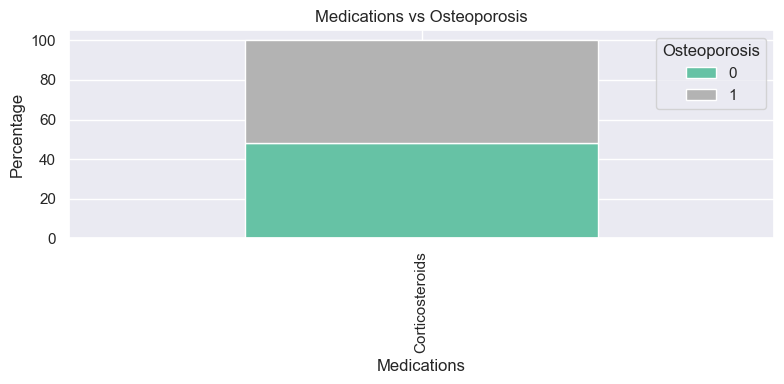

In [17]:
def plot_feature_vs_target(df, feature, target):
    if feature not in df.columns or target not in df.columns:
        return
    plt.figure(figsize=(8,4))
    if df[feature].dtype.name in ['object','category'] or df[feature].nunique() < 10:
        ct = pd.crosstab(df[feature], df[target], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, colormap='Set2', figsize=(8,4))
        plt.ylabel('Percentage')
    else:
        sns.boxplot(x=target, y=feature, data=df, palette='Set2')
    plt.title(f'{feature} vs {target}')
    plt.tight_layout()
    plt.show()

features_of_interest = ['Age','age','Hormonal_change','HormonalChanges','Smoking','smoking','Alcohol','alcohol','Physical_activity','PhysicalActivity','Calcium_intake','CalciumIntake','Medical_conditions','Medications','Family_history','FamilyHistory']
for f in features_of_interest:
    if f in df.columns and target is not None:
        plot_feature_vs_target(df, f, target)

## Multivariate analysis
Correlation heatmap and pairwise relationships to identify collinearity and strong predictors.

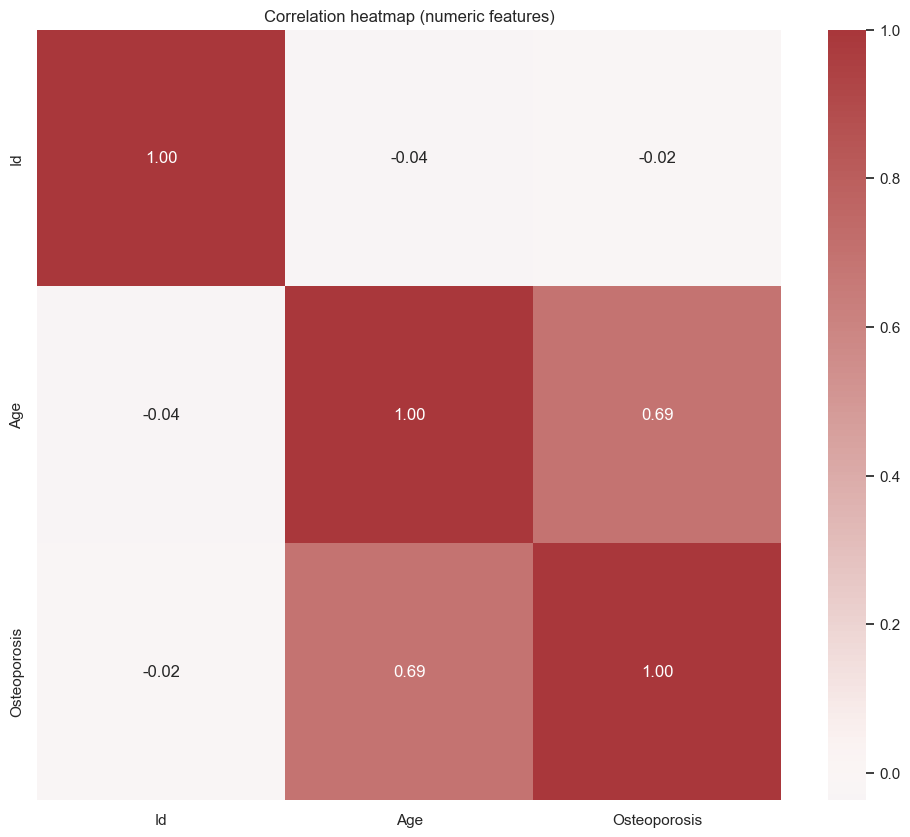

In [18]:
# Correlation heatmap for numeric features
corr = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation heatmap (numeric features)')
plt.show()

## Feature Engineering
Create age groups, BMI groups, and a simple lifestyle risk score if the required columns exist.

In [19]:
# Age grouping
age_col = None
for cand in ['Age','age','AGE']:
    if cand in df.columns:
        age_col = cand
        break
if age_col is not None:
    df['age_group'] = pd.cut(df[age_col], bins=[0,30,45,60,75,120], labels=['<30','30-45','45-60','60-75','75+'])
    print('Added `age_group` from', age_col)
else:
    print('No age column found; skipping age groups')

# BMI grouping if BMI present
bmi_col = None
for cand in ['BMI','bmi','Body_Mass_Index','BodyMassIndex']:
    if cand in df.columns:
        bmi_col = cand
        break
if bmi_col is not None:
    df['bmi_group'] = pd.cut(df[bmi_col], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])
    print('Added `bmi_group` from', bmi_col)
else:
    print('No BMI column found; skipping BMI groups')

# Lifestyle risk scoring (simple additive)
score = np.zeros(len(df))
if 'Smoking' in df.columns or 'smoking' in df.columns:
    scol = 'Smoking' if 'Smoking' in df.columns else 'smoking'
    score += df[scol].apply(lambda x: 1 if str(x).lower() in ['yes','y','smoker','1','true'] else 0)
if 'Alcohol' in df.columns or 'alcohol' in df.columns:
    acol = 'Alcohol' if 'Alcohol' in df.columns else 'alcohol'
    score += df[acol].apply(lambda x: 1 if str(x).lower() in ['yes','y','1','true'] else 0)
if 'Physical_activity' in df.columns or 'PhysicalActivity' in df.columns:
    pcol = 'Physical_activity' if 'Physical_activity' in df.columns else 'PhysicalActivity'
    score += df[pcol].apply(lambda x: 0 if str(x).lower() in ['yes','active','regular'] else 1)

if score.sum() > 0:
    df['lifestyle_risk_score'] = score
    print('Added `lifestyle_risk_score`')
else:
    print('No lifestyle columns found to compute risk score')

Added `age_group` from Age
No BMI column found; skipping BMI groups
Added `lifestyle_risk_score`


## Data Preprocessing (Encoding, Scaling, Split)
Prepare pipelines for numeric and categorical features, then split into train/test sets.

In [20]:
# Prepare feature matrix X and label y
if target is None:
    raise ValueError('Target column not set. Please set `target` to the label column name.')
y = df[target]
X = df.drop(columns=[target])

# Recompute numeric and categorical after feature engineering additions
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
print('Final numeric cols:', num_cols)
print('Final categorical cols:', cat_cols)

# Build preprocessing transformer
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if y.nunique()>1 else None)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Final numeric cols: ['Id', 'Age', 'lifestyle_risk_score']
Final categorical cols: ['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures', 'age_group']
Train size: (1566, 17) Test size: (392, 17)


## Model Building — Baseline models
We'll define pipelines combining preprocessing with model estimators for Logistic Regression, Decision Tree, Random Forest, SVC, and XGBoost (if available). Then we will run a quick baseline comparison with cross-validation.

In [21]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'SVC': SVC(probability=True, class_weight='balanced', random_state=42)
}
if XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    results.append({'model': name, 'roc_auc_mean': np.mean(cv_scores), 'roc_auc_std': np.std(cv_scores)})
    print(f'{name}: ROC-AUC CV mean={np.mean(cv_scores):.3f} std={np.std(cv_scores):.3f}')

results_df = pd.DataFrame(results).sort_values(by='roc_auc_mean', ascending=False)
results_df

LogisticRegression: ROC-AUC CV mean=0.903 std=0.010
DecisionTree: ROC-AUC CV mean=0.854 std=0.025
RandomForest: ROC-AUC CV mean=0.902 std=0.018
SVC: ROC-AUC CV mean=0.888 std=0.016
XGBoost: ROC-AUC CV mean=0.923 std=0.014


,model,roc_auc_mean,roc_auc_std
4,XGBoost,0.923205,0.013791
0,LogisticRegression,0.903313,0.009691
2,RandomForest,0.902228,0.018217
3,SVC,0.887967,0.016138
1,DecisionTree,0.854414,0.024658


## Hyperparameter Tuning (GridSearchCV)
Perform grid search for the top candidate models to optimize key hyperparameters. We'll tune RandomForest and XGBoost (if available) and SVC.

In [22]:
param_grids = {}
param_grids['RandomForest'] = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 6, 12],
    'clf__min_samples_split': [2,5]
}
param_grids['SVC'] = {
    'clf__C': [0.1,1,10],
    'clf__kernel': ['rbf','linear'],
    'clf__gamma': ['scale','auto']
}
if XGB_AVAILABLE:
    param_grids['XGBoost'] = {
        'clf__n_estimators':[100,200],
        'clf__max_depth':[3,6],
        'clf__learning_rate':[0.05,0.1]
    }

best_models = {}
for name in ['RandomForest','SVC'] + (['XGBoost'] if XGB_AVAILABLE else []):
    print('Tuning', name)
    model = models[name] if name in models else None
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', model)])
    grid = GridSearchCV(pipe, param_grids[name], cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    print(name, 'best ROC-AUC:', grid.best_score_, 'best params:', grid.best_params_)
    best_models[name] = grid.best_estimator_

Tuning RandomForest
Fitting 3 folds for each of 12 candidates, totalling 36 fits
RandomForest best ROC-AUC: 0.9141136115637369 best params: {'clf__max_depth': 6, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Tuning SVC
Fitting 3 folds for each of 12 candidates, totalling 36 fits
SVC best ROC-AUC: 0.9068862758914285 best params: {'clf__C': 0.1, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Tuning XGBoost
Fitting 3 folds for each of 8 candidates, totalling 24 fits
XGBoost best ROC-AUC: 0.9335104691162295 best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100}


## Evaluate Final Models on Test Set
Compare tuned models and baseline candidates on held-out test set using accuracy, precision, recall, F1, ROC-AUC and plot ROC / PR curves and confusion matrices.

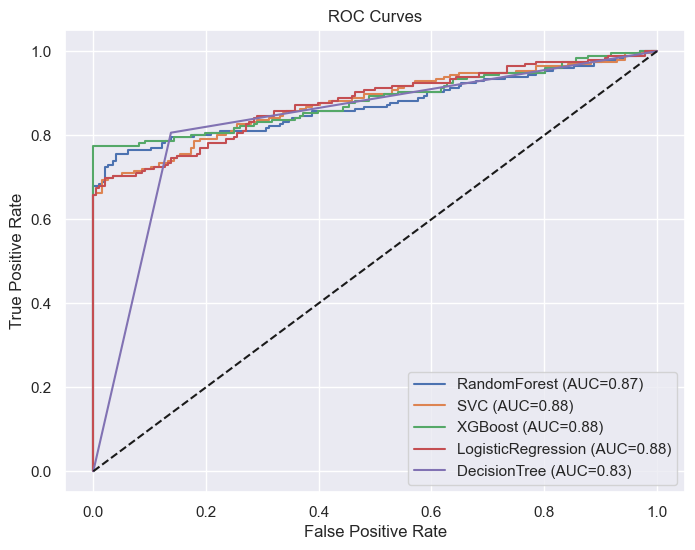

,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.885204,1.000000,0.770408,0.870317,0.884241
3,LogisticRegression,0.816327,0.907895,0.704082,0.793103,0.877994
1,SVC,0.806122,0.865854,0.724490,0.788889,0.877213
0,RandomForest,0.846939,0.972222,0.714286,0.823529,0.872189
4,DecisionTree,0.834184,0.854054,0.806122,0.829396,0.834184


In [23]:
eval_results = []
candidates = {}
# include tuned models where available, else baseline pipelines
for name, model in best_models.items():
    candidates[name] = model
for name, model in models.items():
    if name not in candidates:
        candidates[name] = Pipeline(steps=[('preprocessor', preprocessor), ('clf', model)])

plt.figure(figsize=(8,6))
for name, estimator in candidates.items():
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)
    y_proba = estimator.predict_proba(X_test)[:,1] if hasattr(estimator, 'predict_proba') else estimator.decision_function(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test))>1 else np.nan
    eval_results.append({'model':name,'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,'roc_auc':roc})
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba) if len(np.unique(y_test))>1 else (None,None,None)
    if fpr is not None:
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

results_eval_df = pd.DataFrame(eval_results).sort_values(by='roc_auc', ascending=False)
results_eval_df

## Feature Importance (Tree-based models)
Display feature importances for RandomForest / XGBoost if available and provide interpretation.

Plotting feature importances for RandomForest


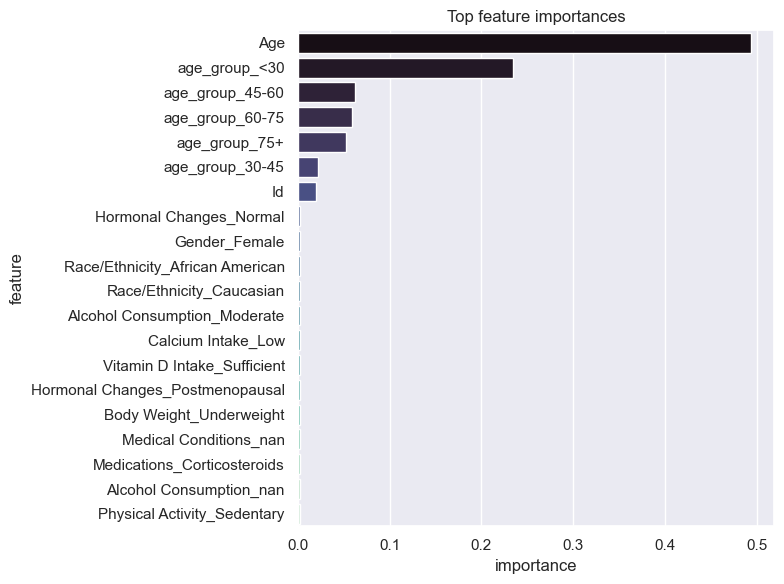

In [24]:
def plot_feature_importance(estimator, preprocessor, X_cols, top_n=20):
    # get feature names after preprocessing
    ohe_cols = []
    if hasattr(preprocessor, 'transformers_'):
        for name, trans, cols in preprocessor.transformers_:
            if name == 'num':
                ohe_cols.extend(cols)
            elif name == 'cat':
                # inspect onehot categories
                try:
                    ohe = trans.named_steps['onehot']
                    cats = ohe.get_feature_names_out(cols)
                    ohe_cols.extend(cats)
                except Exception:
                    ohe_cols.extend(cols)
    if hasattr(estimator.named_steps['clf'], 'feature_importances_'):
        importances = estimator.named_steps['clf'].feature_importances_
        feat_df = pd.DataFrame({'feature': ohe_cols, 'importance': importances})
        feat_df = feat_df.sort_values('importance', ascending=False).head(top_n)
        plt.figure(figsize=(8,6))
        sns.barplot(x='importance', y='feature', data=feat_df, palette='mako')
        plt.title('Top feature importances')
        plt.tight_layout()
        plt.show()

# Find a tree-based winner and plot its importances
tree_winner = None
for name in ['RandomForest','XGBoost','DecisionTree']:
    if name in candidates:
        est = candidates[name]
        if hasattr(est.named_steps['clf'], 'feature_importances_'):
            tree_winner = name
            break
if tree_winner is not None:
    print('Plotting feature importances for', tree_winner)
    plot_feature_importance(candidates[tree_winner], preprocessor, X.columns)
else:
    print('No tree-based model with feature_importances_ available to plot')

## Final Insights, Conclusions & Recommendations
Summarize the key findings and provide healthcare-focused recommendations for early interventions based on model insights.

**Key takeaways (to be completed after running notebook):**
- Age groups with highest predicted risk
- Impact of lifestyle factors (smoking, alcohol, low physical activity)
- Influence of hormonal changes and medications
- Most important predictive features from the model

**Recommendations for healthcare providers:**
- Targeted screening for high-risk age groups identified by the model
- Lifestyle intervention programs for smokers and those with high `lifestyle_risk_score`
- Nutritional counseling and calcium/vitamin D supplementation where low intake identified
- Closer monitoring of patients with relevant medical history and family history of osteoporosis

---
**Next steps / Extras you can add:**
- Use SHAP for explainability (SHAP dependency)
- Deploy best model as a lightweight API for clinical decision support
- Add more advanced imputation for clinical variables and incorporate temporal data if available

## Requirements & How to run
Install the required packages and run the notebook end-to-end. A minimal `requirements.txt` should include:
- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- xgboost (optional)
- imbalanced-learn (optional for SMOTE)

Run the notebook cells from top to bottom. Replace/confirm the detected `target` column if auto-detection did not find it.